In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")
from diffPLOG2TROE.rate_constants import FallOff
from diffPLOG2TROE.rate_constants import Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter
from diffPLOG2TROE.optimization import LossType

import matplotlib.pyplot as plt

In [3]:
starting_plog = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03],
        ]
    },
}

param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},    
}

refitter = PlogRefitter(
    starting_plog,
    T_range=(500, 2500),
    P_range=(0.1, 100),
    n_T=300,
    n_P=300,
    param_config=param_config,
    loss_name="log",
    log_name="nlopt-refit.log"
)

nlopt_options = {
    "algorithm": "LBFGS",
    "max_eval": 1000000,
    "ftol_rel": 1e-15,
    "xtol_rel": 1e-15,
    "steps_file": 1000
}

initial_troe = refitter.fit(nlopt_options=nlopt_options)
print(FallOff(initial_troe))

Plog 2 TROE refitter
 Temperature range [K]: (500, 2500)
 Pressure range [atm]: (0.1, 100)
 Loss function: log

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: fixed at 1.50000e+14
  n_high: fixed at 1.67000e-01
  E_high: fixed at 0.00000e+00
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value
Starting optimization
First guess estimate of the parameters:
  High pressure limit (A, n, Ea): 1.500e+14, 0.167, 0.000e+00
  Low pressure limit (A, n, Ea): 1.213e+27, -4.959, 2.807e+03
  Troe parameters (A, T3, T1, T2): 0.500, 1.050e+03, 3.000e+02, 2.250e+03

  Step 0: loss = 1.359470e+01, Gradient norm: 7.271676e+00
  Step 1000: loss = 3.564653e-02, Gradient norm: 1.005049e-02
  Step 2000: loss = 3.307791e-02, Gradient norm: 3.819230e-02
NLOpt fin

NH2+H=NH3		1.50000e+14 0.16700 0.00000e+00
 LOW / 		5.84809e+29 -3.84962 2.70486e+03 /
 TROE / 5.37870e-01 2.26443e+03 3.18384e+01 7.23367e+03 /


Minimum error: 0.8427008592016484
Maximum error: 1.0875902185633552
Average error: 0.9994930338439647


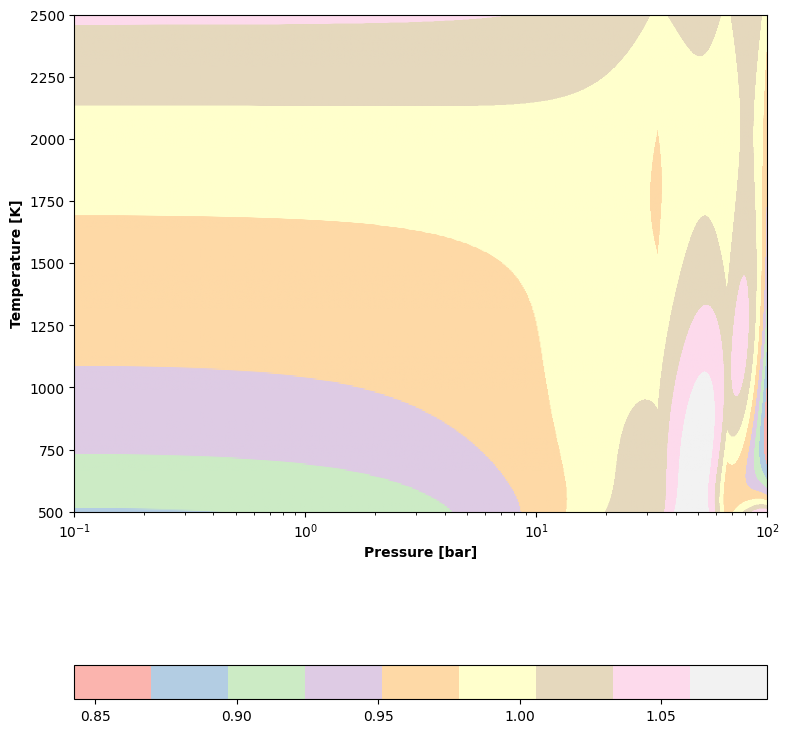

In [4]:
T_range = jnp.linspace(500, 2500, 1000)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 1000)

T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

falloff = FallOff(initial_troe)
plog = Plog(starting_plog)
k_falloff_map = falloff.kinetic_constant(T_range, P_range)
k_plog_map = plog.kinetic_constant(T_range, P_range)
    
ratio = k_falloff_map.T / k_plog_map.T

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel1"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {jnp.mean(ratio)}")

plt.tight_layout()
plt.show()

In [7]:
starting_plog = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03],
        ]
    },
}

param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},    
}

refitter = PlogRefitter(
    starting_plog,
    T_range=(500, 2500),
    P_range=(0.1, 100),
    n_T=300,
    n_P=300,
    param_config=param_config,
    loss_name="rel-abs",
    log_name="nlopt-refit.log"
)

nlopt_options = {
    "algorithm": "LBFGS",
    "max_eval": 1000000,
    "ftol_rel": 1e-15,
    "xtol_rel": 1e-15,
    "steps_file": 1000
}

initial_troe = refitter.fit(nlopt_options=nlopt_options)
print(FallOff(initial_troe))

Plog 2 TROE refitter
 Temperature range [K]: (500, 2500)
 Pressure range [atm]: (0.1, 100)
 Loss function: rel-abs

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: fixed at 1.50000e+14
  n_high: fixed at 1.67000e-01
  E_high: fixed at 0.00000e+00
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value
Starting optimization
First guess estimate of the parameters:
  High pressure limit (A, n, Ea): 1.500e+14, 0.167, 0.000e+00
  Low pressure limit (A, n, Ea): 1.213e+27, -4.959, 2.807e+03
  Troe parameters (A, T3, T1, T2): 0.500, 1.050e+03, 3.000e+02, 2.250e+03

  Step 0: loss = 9.999963e-01, Gradient norm: 2.527012e-05
  Step 1000: loss = 1.170891e-03, Gradient norm: 1.872377e-05
NLOpt finished with status: 1 - Success: Generic success return val

NH2+H=NH3		1.50000e+14 0.16700 0.00000e+00
 LOW / 		6.97242e+29 -3.87140 2.74805e+03 /
 TROE / 5.39610e-01 2.25118e+03 3.66294e+01 7.10658e+03 /


Minimum error: 0.839490408331384
Maximum error: 1.0798550679908792
Average error: 0.997982471367453


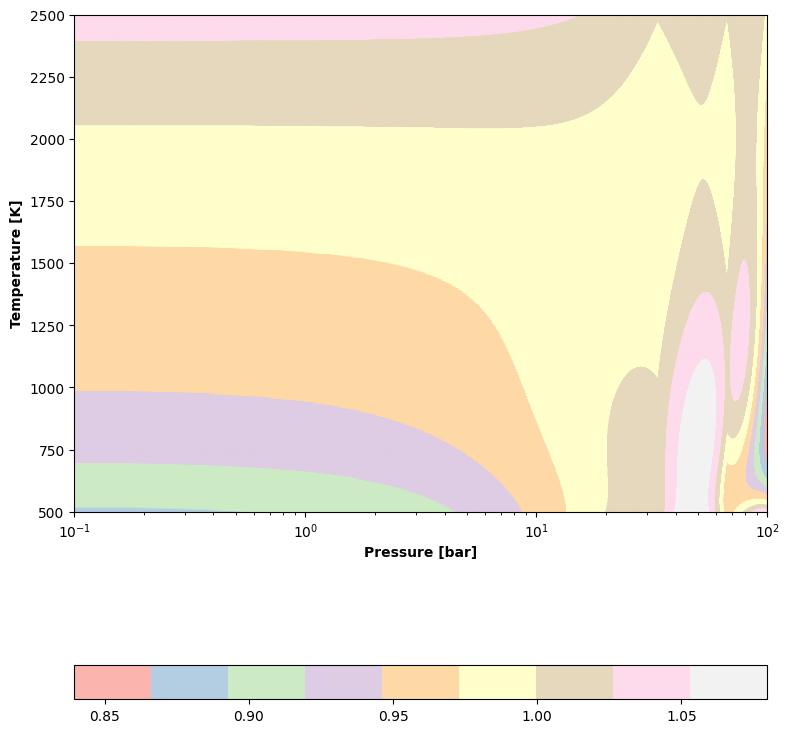

In [8]:
T_range = jnp.linspace(500, 2500, 1000)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 1000)

T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

falloff = FallOff(initial_troe)
plog = Plog(starting_plog)
k_falloff_map = falloff.kinetic_constant(T_range, P_range)
k_plog_map = plog.kinetic_constant(T_range, P_range)
    
ratio = k_falloff_map.T / k_plog_map.T

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel1"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {jnp.mean(ratio)}")

plt.tight_layout()
plt.show()